## ****EVALUATION (EVALUASI)****

---

Tahap penutup CRISP-DM ini menilai apakah hasil pemodelan memenuhi kriteria sukses pada Business Understanding, menafsirkan model menjadi insight bisnis, dan menyusun saran strategis. Tahap ini menggabungkan temuan dari seluruh notebook sebelumnya: pola pemakaian dari Data Understanding, keputusan rekayasa fitur dari Data Preparation, dan performa model dari Modeling.

### ****EVALUASI TERHADAP KRITERIA SUKSES****

Business Understanding menetapkan dua kriteria Measurable: RMSE yang mengungguli baseline sederhana dan seminimal mungkin pada leaderboard, serta laporan yang memuat interpretasi model, faktor paling berpengaruh, dan rekomendasi strategis.

| Kriteria | Target | Capaian |
|---|---|---|
| RMSE leaderboard vs baseline global mean (CV 0,3190) | Lebih rendah | 0,06827 (turun 78,6%) |
| RMSE leaderboard vs baseline loc_hour_target_mean (CV 0,1429) | Lebih rendah | 0,06827 (turun 52,2%) |
| RMSE leaderboard seminimal mungkin | Terus diturunkan | 0,07315 → 0,06852 → 0,06844 → 0,06832 → 0,06827 lewat 5 submission |
| Interpretasi model | Tersedia | Bagian C dan D |
| Faktor paling berpengaruh | Tersedia | Bagian D |
| Minimal 3 rekomendasi strategis | Tersedia | Bagian F |

Model final jauh mengungguli kedua baseline, dan proses penurunan RMSE terdokumentasi lengkap di notebook Modeling (termasuk eksperimen yang gagal, bukan cuma yang berhasil). Sisa bagian evaluasi ini memenuhi tiga kriteria kualitatif yang tersisa.

### ****INTERPRETASI MODEL: FEATURE IMPORTANCE****

Memuat model LightGBM final (v5, dilatih dengan pembobotan recency pada seluruh data) dan menghitung feature importance-nya. LightGBM dipilih untuk interpretasi karena importance-nya langsung tersedia dan mudah dijelaskan, mewakili ketiga model dalam blend karena polanya serupa (dikonfirmasi pada Modeling: ketiga model membuat kesalahan yang sangat mirip).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb

CLEAN_DIR = "../Dataset/Clean"
TARGET_COL = "utilization_rate"

Jumlah fitur: 28


,importance_gain,persen
station_hour_weekend_target_mean,68564.007728,98.1
weather_condition_code,418.273363,0.6
station_hour_target_mean,289.450668,0.4
month,254.736427,0.4
precipitation_mm,70.820251,0.1
temperature_f,70.626713,0.1
day_of_week,53.581396,0.1
station_target_mean,45.269440,0.1
loc_hour_target_mean,34.639065,0.0
dow_sin,26.922136,0.0


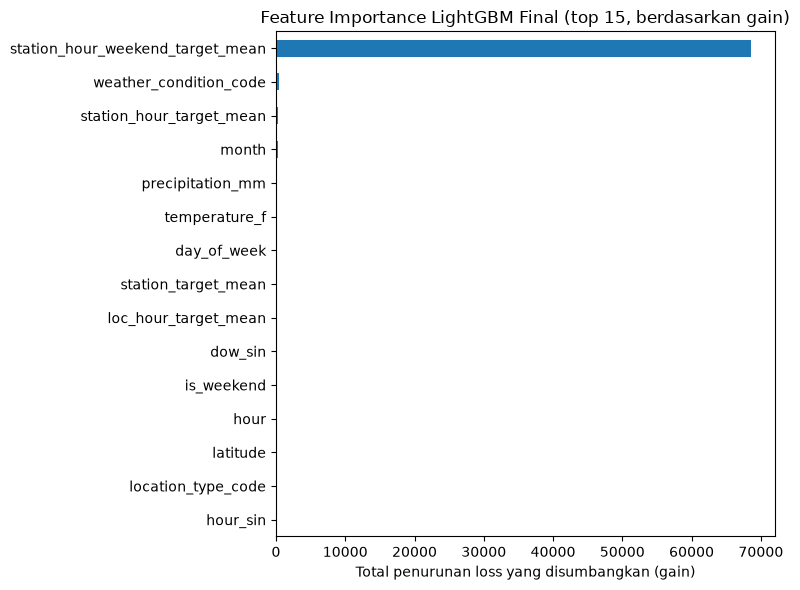

In [2]:
lgb_final = lgb.Booster(model_file=f"{CLEAN_DIR}/model_lightgbm_final_v5.txt")
feature_names = lgb_final.feature_name()

feature_importance = pd.Series(
    lgb_final.feature_importance(importance_type="gain"),
    index=feature_names,
).sort_values(ascending=False)

feature_importance_share = (feature_importance / feature_importance.sum() * 100).round(1)

print(f"Jumlah fitur: {len(feature_names)}")
display(pd.DataFrame({"importance_gain": feature_importance, "persen": feature_importance_share}).head(15))

feature_importance.head(15).sort_values().plot.barh(
    figsize=(8, 6), title="Feature Importance LightGBM Final (top 15, berdasarkan gain)"
)
plt.xlabel("Total penurunan loss yang disumbangkan (gain)")
plt.tight_layout()
plt.show()

#### Feature Importance: Gain vs Split

Gain mengukur total penurunan error yang disumbangkan tiap fitur, sedangkan split mengukur seberapa sering fitur dipakai untuk membelah pohon. Keduanya disandingkan karena gain sendirian bisa menyembunyikan kontribusi fitur lain yang dipakai berulang kali dengan dampak kecil per pemakaian, padahal secara kumulatif tetap berarti.

,gain_persen,split_rank,split_count
station_hour_weekend_target_mean,98.1,1,699
weather_condition_code,0.6,4,191
station_hour_target_mean,0.4,8,92
month,0.4,5,171
day_of_week,0.1,9,83
temperature_f,0.1,7,106
station_target_mean,0.1,3,192
precipitation_mm,0.1,6,149
dow_sin,0.0,11,36
charger_type_code,0.0,21,3


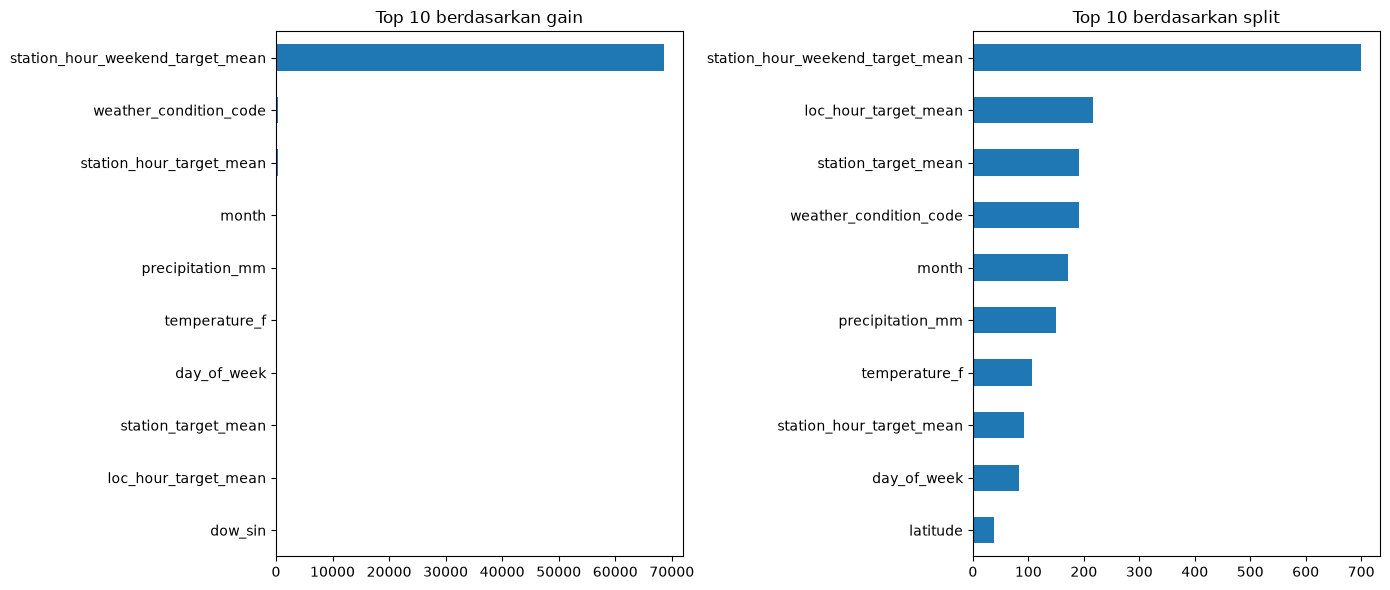

In [3]:
feature_importance_split = pd.Series(
    lgb_final.feature_importance(importance_type="split"),
    index=feature_names,
).sort_values(ascending=False)

importance_comparison = pd.DataFrame({
    "gain_persen": feature_importance_share,
    "split_rank": feature_importance_split.rank(ascending=False).astype(int),
    "split_count": feature_importance_split,
}).sort_values("gain_persen", ascending=False)

display(importance_comparison.head(15))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
feature_importance.head(10).sort_values().plot.barh(ax=axes[0], title="Top 10 berdasarkan gain")
feature_importance_split.head(10).sort_values().plot.barh(ax=axes[1], title="Top 10 berdasarkan split")
plt.tight_layout()
plt.show()

### ****FAKTOR PALING BERPENGARUH****

Kedua ukuran importance (gain dan split) sepakat pada urutan yang sama untuk empat fitur teratas, meski skalanya berbeda jauh. Split (seberapa sering fitur dipakai untuk membelah data) memberi gambaran yang lebih seimbang untuk narasi bisnis dibanding gain yang didominasi satu fitur.

**1. Pola historis stasiun pada jam dan tipe hari tertentu** (station_hour_weekend_target_mean, split tertinggi 699 kali, gain 98,1%)

Fitur paling berpengaruh bukan satu variabel mentah, melainkan rangkuman kombinasi tiga faktor: stasiun mana, jam berapa, dan hari kerja atau akhir pekan. Ini mengonfirmasi temuan inti Data Understanding: pola jam berbeda drastis antarstasiun karena tipe lokasinya (Workplace ramai siang, Residential ramai malam, Shopping Center dan Urban Center dua puncak), dan akhir pekan konsisten lebih rendah 0,035 sampai 0,04 dibanding hari kerja. Model belajar bahwa sejarah pemakaian tiap stasiun pada kombinasi jam dan tipe hari tertentu adalah prediktor terkuat pemakaian di masa depan.

**2. Pola tipe lokasi dan jam** (loc_hour_target_mean, split kedua 216 kali)

Terlepas dari sejarah stasiun individunya, tipe lokasi (Shopping Center, Residential, Workplace, dan seterusnya) dikombinasikan dengan jam tetap menjadi sinyal kuat tersendiri. Ini relevan untuk stasiun baru yang belum punya riwayat panjang, karena rekomendasi penempatan bisa bersandar pada pola tipe lokasi yang sudah terbukti.

**3. Karakteristik dasar tiap stasiun** (station_target_mean, split ketiga 192 kali)

Popularitas rata-rata satu stasiun, terlepas dari waktu, tetap berpengaruh signifikan. Sejalan dengan Data Understanding: rata-rata utilization antarstasiun berkisar 0,22 sampai 0,64, dan sebagian bergantung pada kota (San Francisco, Seattle, Los Angeles secara konsisten lebih tinggi).

**4. Kondisi cuaca** (weather_condition_code, split keempat 191 kali, plus temperature_f dan precipitation_mm mentah di peringkat 6 dan 7)

Cuaca memiliki pengaruh yang bersifat berambang (threshold), bukan linear sederhana: extreme_heat dan freezing menaikkan pemakaian (orang menghindari mengisi daya sambil berjalan jauh dalam cuaca ekstrem, memilih menunggu di dekat charger), sementara hujan lebat justru menurunkannya tajam. Pola ini pertama kali ditemukan lewat analisis uplift pada Data Understanding, dan feature importance mengonfirmasi model benar-benar memanfaatkannya.

**5. Musim dan siklus mingguan** (month peringkat kelima 171 kali, day_of_week dan dow_sin menyusul)

Perubahan level bulanan yang ditemukan pada Data Understanding (naik turun berundak mengikuti rezim suhu dan harga bensin) dan siklus mingguan (akhir pekan vs hari kerja) sama-sama terpakai signifikan oleh model, meski levelnya di bawah empat faktor sebelumnya.

**Faktor dengan pengaruh kecil**: koordinat lokasi (latitude, split hanya 38), tipe lokasi sebagai kode kategorik langsung (location_type_code), dan charger_type_code. Ini bukan berarti lokasi dan jenis charger tidak penting, tapi pengaruhnya sudah terserap lewat station_target_mean dan loc_hour_target_mean yang lebih granular, sehingga informasinya redundan bagi model meski tetap relevan bagi manusia yang membaca hasilnya.

**Faktor yang ternyata nyaris tidak berpengaruh**: gas_price_per_gallon dan local_event tidak masuk 15 besar pada kedua ukuran importance. Untuk local_event, ini sejalan dengan temuan Data Understanding (uplift mendekati nol untuk semua jenis acara). Untuk harga bensin, pengaruhnya kemungkinan besar sudah terserap oleh month dan temperature_f yang bergerak bersamaan (harga naik tepat saat suhu turun di November), sehingga sulit dipisahkan sebagai faktor independen.

### ****KETERBATASAN MODEL****

**1. Bergantung berat pada riwayat tiap stasiun**

Fitur paling berpengaruh (station_hour_weekend_target_mean) adalah rata-rata historis stasiun itu sendiri. Model ini akan langsung tidak akurat untuk stasiun baru yang belum punya riwayat, karena hanya bisa jatuh ke rata-rata tipe lokasi yang jauh lebih kasar. Model ini cocok untuk mengoptimalkan 150 stasiun yang sudah ada, bukan untuk memprediksi performa stasiun yang belum dibangun.

**2. Ketidakpastian lebih lebar pada jam sibuk**

Analisis residual pada Modeling menemukan RMSE tertinggi justru pada jam 11 sampai 18, bukan karena model salah arah (bias rata-rata mendekati nol di semua jam), tapi karena permintaan pada jam sibuk secara alami lebih fluktuatif. Artinya prediksi pada jam ramai punya rentang ketidakpastian lebih lebar daripada jam sepi, hal yang perlu diperhitungkan sebelum dipakai untuk keputusan operasional seperti penjadwalan staf.

**3. RMSE sudah mendekati batas noise struktural data**

Lebih dari 15 eksperimen fitur dan model (target encoding lebih tajam, tiga arsitektur model berbeda, stacking, transformasi target, pembobotan waktu) hanya menurunkan RMSE dari 0,07315 ke 0,06827, dengan perbaikan yang makin mengecil di tiap percobaan terakhir. Ini indikasi kuat bahwa sisa error bersifat acak bawaan data, bukan pola yang masih bisa ditangkap dengan rekayasa fitur lebih lanjut.

**4. Periode data hanya mencakup satu musim dingin**

Train dan test sama-sama berasal dari satu rentang waktu (Juli sampai Desember 2025). Performa model pada musim semi atau panas tahun berikutnya, atau pada tren adopsi EV jangka panjang, belum pernah teruji.

**5. Tidak memanfaatkan konteks dunia nyata**

Aturan lomba melarang data eksternal, sehingga model tidak bisa memakai kalender hari libur nasional yang sesungguhnya, kejadian cuaca ekstrem aktual, atau data lalu lintas riil, meski faktor-faktor itu disinggung di latar belakang soal.

**6. RMSE memperlakukan semua arah kesalahan setara**

RMSE tidak membedakan dampak memprediksi terlalu rendah (berisiko slot penuh dan antrean tak terduga) dengan memprediksi terlalu tinggi (berisiko kapasitas menganggur). Kedua jenis kesalahan punya konsekuensi operasional yang berbeda bagi operator dan pemerintah, sesuatu yang tidak tertangkap satu angka RMSE saja.

**7. Model bersifat menangkap pola historis, bukan mengantisipasi perubahan struktural**

Karena mengandalkan rata rata historis, model tidak bisa mengantisipasi kejadian yang belum pernah terjadi di data latih, seperti pembukaan stasiun pesaing baru, perubahan skema harga besar besaran, atau lonjakan adopsi EV yang tiba tiba.

### ****SARAN STRATEGIS****

Tiga rekomendasi berikut menjawab pertanyaan ketiga Business Understanding (strategi bagi pemerintah dan penyedia layanan), disusun berdasarkan temuan Bagian D dan Data Understanding, sejalan dengan SDG 7 (efisiensi energi bersih) dan SDG 4 (insight berbasis data untuk perencanaan kebijakan).

**1. Penyeimbangan kapasitas berdasarkan pola tipe lokasi dan jam**

Data Understanding menunjukkan rata-rata utilization berkisar dari 0,27 (Residential) dan 0,29 (Workplace) sampai 0,48 (Shopping Center), persis pola ketimpangan yang disebut di latar belakang soal: antrean panjang di lokasi padat, stasiun sepi di lokasi lain. Karena loc_hour_target_mean menjadi salah satu faktor paling berpengaruh (Bagian D), profil jam per tipe lokasi ini bisa dipakai operator untuk menambah port pengisian di Shopping Center dan Urban Center pada jam 11 sampai 18 (jam dengan RMSE dan permintaan tertinggi), sekaligus mengevaluasi apakah kapasitas di Residential dan Workplace bisa dikurangi atau dialihfungsikan.

**2. Kesiapan operasional berbasis ambang cuaca, bukan cuaca harian**

Feature importance dan analisis uplift Data Understanding sama-sama menunjukkan pengaruh cuaca bersifat berambang: extreme_heat dan freezing menaikkan pemakaian, sementara hujan lebat menurunkannya tajam. Pemerintah dan operator dapat menyiapkan protokol kesiapan (staf tambahan, pemantauan antrean) khusus saat prakiraan cuaca menunjukkan suhu ekstrem, tanpa perlu menyiagakan sumber daya berlebih pada hari hujan ringan biasa yang ternyata tidak berpengaruh signifikan terhadap permintaan.

**3. Estimasi kapasitas stasiun baru memakai profil tipe lokasi, bukan tebakan seragam**

Keterbatasan model (Bagian E) menunjukkan stasiun baru tidak punya riwayat sehingga sulit diprediksi akurat lewat station_target_mean. Sebagai jalan tengah, perencana kota dapat memakai loc_hour_target_mean, yaitu profil rata-rata tipe lokasi sejenis, sebagai estimasi awal kapasitas (jumlah port, jenis charger) sebelum stasiun baru punya cukup riwayat operasional sendiri, mengurangi risiko under atau over investasi di lokasi baru.

**4. Dasbor pemantauan sebagai alat edukasi publik dan perencanaan (SDG 4)**

Karena RMSE memperlakukan prediksi terlalu tinggi dan terlalu rendah secara setara (Bagian E), keputusan operasional sebaiknya tidak bersandar pada satu angka prediksi saja. Model ini lebih tepat diwujudkan sebagai dasbor pemantauan tingkat pemakaian per lokasi dan jam bagi perencana kota, yang sekaligus menjadi bahan edukasi publik tentang pola kepadatan stasiun EV, selaras dengan SDG 4 sebagai sumber belajar berbasis data, bukan sekadar alat prediksi tunggal.

**5. Evaluasi berkala mengikuti keterbatasan data**

Karena model hanya teruji pada satu periode Juli sampai Desember 2025 (Bagian E), performa dan rekomendasi ini perlu dievaluasi ulang secara berkala, terutama setelah musim berganti atau ada perubahan besar seperti stasiun pesaing baru atau perubahan skema harga, agar tetap relevan dengan kondisi terkini.

### ****MENJAWAB PERTANYAAN PENELITIAN****

Business Understanding merumuskan tiga pertanyaan inti. Berikut jawabannya berdasarkan seluruh tahap CRISP-DM yang sudah dilalui.

**1. Seberapa akurat utilization_rate dapat diprediksi dari faktor temporal, spasial, harga, cuaca, dan acara lokal?**

Model akhir mencapai RMSE 0,06827 pada leaderboard, turun 78,6% dari baseline rata-rata global (0,3190) dan 52,2% dari baseline loc_hour_target_mean (0,1429). Namun akurasi ini tidak merata: prediksi lebih andal pada jam sepi dan stasiun dengan riwayat panjang, sementara jam sibuk (11-18) punya ketidakpastian lebih lebar karena volatilitas permintaan yang memang tinggi secara alami (Bagian E). Dari lima kelompok faktor yang disebut di rumusan masalah, temporal dan spasial (riwayat stasiun) terbukti paling prediktif, cuaca berpengaruh secara berambang, harga bensin tumpang tindih dengan musim sehingga sulit dipisahkan, dan acara lokal ternyata nyaris tidak berpengaruh.

**2. Faktor apa yang paling berpengaruh terhadap utilization_rate?**

Berdasarkan Bagian D, urutannya: riwayat historis stasiun pada kombinasi jam dan tipe hari, pola tipe lokasi per jam, karakteristik dasar tiap stasiun, kondisi cuaca (berambang, bukan linear), lalu musim dan siklus mingguan. Faktor harga bensin dan acara lokal, meski disebut eksplisit di latar belakang soal, ternyata berpengaruh kecil hingga nyaris tidak berpengaruh terhadap target.

**3. Strategi apa yang dapat dilakukan pemerintah dan penyedia layanan untuk memeratakan pemanfaatan dan meningkatkan QoS?**

Lima strategi dirumuskan di Bagian F: penyeimbangan kapasitas berbasis pola tipe lokasi dan jam, kesiapan operasional berbasis ambang cuaca, estimasi kapasitas stasiun baru memakai profil tipe lokasi sejenis, dasbor pemantauan sebagai alat edukasi dan perencanaan, serta evaluasi berkala mengikuti keterbatasan data.

### ****KESIMPULAN DAN RENCANA TINDAK LANJUT****

**Kesimpulan**

Proyek ini berhasil membangun model regresi spasial-temporal untuk memprediksi utilization_rate stasiun pengisian EV, mencapai RMSE 0,06827 pada leaderboard Kaggle lewat lima iterasi submission yang terdokumentasi lengkap di notebook Modeling, termasuk lebih dari 15 eksperimen yang gagal maupun berhasil. Seluruh kriteria sukses pada Business Understanding terpenuhi: RMSE jauh mengungguli kedua baseline, dan laporan memuat interpretasi model, faktor paling berpengaruh, serta rekomendasi strategis yang berdasar temuan data, bukan asumsi.

Satu temuan metodologis penting sepanjang proyek adalah terungkapnya bias pada skema validasi silang awal (Modeling, Fase J), yang kemudian diperbaiki dan mengubah arah sejumlah keputusan tuning. Analisis residual pada model final juga mengonfirmasi tidak ada bias sistematis tersisa pada segmen manapun, memperkuat bahwa RMSE yang dicapai sudah mendekati batas noise struktural data, bukan keterbatasan usaha eksplorasi.

**Rencana tindak lanjut**

1. Mengumpulkan data lintas musim (lebih dari satu tahun) untuk menguji apakah pola yang ditemukan bertahan di luar periode Juli-Desember 2025.
2. Membangun mekanisme pembaruan berkala untuk fitur riwayat stasiun, mengingat model sangat bergantung pada station_hour_weekend_target_mean yang perlu terus diperbarui seiring data baru masuk.
3. Menguji model pada stasiun yang benar-benar baru begitu tersedia, untuk memvalidasi keterbatasan yang disebut di Bagian E secara langsung.
4. Mengembangkan dasbor pemantauan (Bagian F, poin 4) sebagai wujud praktis dari model ini bagi perencana kota dan operator.

<div align="center">
  <img src="https://i.pinimg.com/1200x/fe/26/bf/fe26bfc0d4298cc52e853513eebb2ea9.jpg" alt="Hanaori Imutt" width="300">
  <h5>Lanjut ke "Evaluation" finally </h5>
</div>